In [38]:
from datascience import *
import numpy as np

%matplotlib inline

import matplotlib.pyplot as plt

In [39]:
scores = Table.read_table("scores_by_section.csv")
scores.show(5)

Section,Midterm
1,22
2,12
2,23
2,14
1,20


In [40]:
scores.group("Section")

Section,count
1,32
2,32
3,27
4,30
5,33
6,32
7,24
8,29
9,30
10,34


In [41]:
grouped = scores.group("Section", collect=np.mean)
grouped

Section,Midterm mean
1,15.5938
2,15.125
3,13.6667
4,14.7667
5,17.4545
6,15.0312
7,16.625
8,16.3103
9,14.5667
10,15.2353


In [42]:
observed_average = grouped.where("Section", 3).column("Midterm mean").item(0)
observed_average

13.666666666666666

In [43]:
random_sample = scores.sample(27, with_replacement=False)
random_sample

Section,Midterm
3,10
1,9
4,14
8,19
11,19
6,11
8,8
1,22
10,19
9,0


In [44]:
np.mean(random_sample.column("Midterm"))

14.74074074074074

In [45]:
def random_sample_midterm_average():
    random_sample = scores.sample(27, with_replacement=False)
    return np.mean(random_sample.column("Midterm"))

In [46]:
sample_averages = make_array()

for i in range(50_000):
    new_avg = random_sample_midterm_average()
    sample_averages = np.append(sample_averages, new_avg)

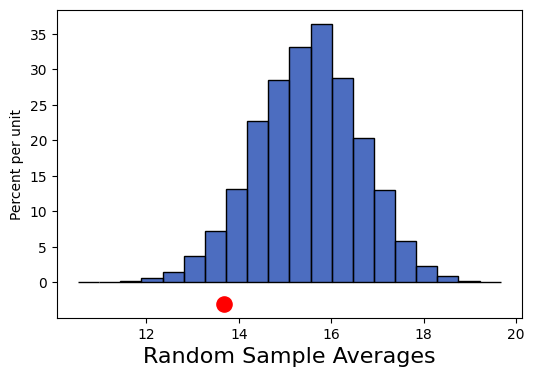

In [47]:
avgs_table = Table().with_column("Random Sample Averages", sample_averages)


avgs_table.hist(bins=20)
plt.scatter(observed_average, -0.03, color="red", s=120)

In [48]:
# Calculate Percent of Sample Average <= Observed Average

np.count_nonzero(sample_averages <= observed_average) / sample_averages.size

0.0569

In [49]:
five_percent_point = avgs_table.sort(0).column(0).item(int(0.05* sample_averages.size))
five_percent_point

13.62962962962963